## 1. Import thư viện & Load artifacts

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAXResults
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Load dữ liệu test ────────────────────────────────────────────────────────
test_df = pd.read_csv('clean_data/clean_data_test.csv')
test_df['time'] = pd.to_datetime(test_df['time'])
test_df = test_df.sort_values('time').reset_index(drop=True)

# ── Load các artifacts đã lưu từ training.ipynb ──────────────────────────────
with open('saved_models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('saved_models/pca.pkl', 'rb') as f:
    pca_final = pickle.load(f)

with open('saved_models/feature_cols_stats.pkl', 'rb') as f:
    feature_cols_stats = pickle.load(f)

## 2. Tái tạo Feature Engineering Pipeline trên tập Test

Áp dụng **đúng thứ tự** các bước FE như đã làm trên train:
1. Chuẩn hóa bằng `scaler` đã fit trên train (chỉ `.transform()`, không `.fit()`)
2. Giảm chiều bằng `pca_final` đã fit trên train (chỉ `.transform()`)
3. Sin/Cos encoding cho giờ và tháng

In [9]:
# ── 2.1 Chuẩn hóa (dùng scaler đã fit trên train) ───────────────────────────
X_test_raw    = test_df[feature_cols_stats].values
X_test_scaled = scaler.transform(X_test_raw)   # chỉ transform, không fit lại

# ── 2.2 PCA (dùng pca_final đã fit trên train) ───────────────────────────────
X_test_pca = pca_final.transform(X_test_scaled)
pca_cols   = [f'PC{i+1}' for i in range(pca_final.n_components_)]

test_pca_df = pd.DataFrame(X_test_pca, columns=pca_cols)
test_pca_df.insert(0, 'time', test_df['time'].values)
test_pca_df['temperature_2m'] = test_df['temperature_2m'].values

# ── 2.3 Sin/Cos encoding ─────────────────────────────────────────────────────
test_pca_df['hour']      = test_df['time'].dt.hour
test_pca_df['month']     = test_df['time'].dt.month
test_pca_df['sin_hour']  = np.sin(2 * np.pi * test_pca_df['hour']  / 24)
test_pca_df['cos_hour']  = np.cos(2 * np.pi * test_pca_df['hour']  / 24)
test_pca_df['sin_month'] = np.sin(2 * np.pi * test_pca_df['month'] / 12)
test_pca_df['cos_month'] = np.cos(2 * np.pi * test_pca_df['month'] / 12)

# ── 2.4 Exog cho SARIMAX: PC1–PC5 + sin/cos (không lag target) ───────────────
# Lý do: lag target trong exog gây Data Leakage khi inference
pca_exog_cols = pca_cols + ['sin_hour', 'cos_hour', 'sin_month', 'cos_month']
X_test_exog   = test_pca_df[pca_exog_cols]
y_test        = test_pca_df['temperature_2m']

print(f"X_test_exog shape : {X_test_exog.shape}")
print(f"y_test shape      : {y_test.shape}")
print(f"Exog columns      : {pca_exog_cols}")
print(f"\n5 dòng đầu X_test_exog:")
print(X_test_exog.head())

X_test_exog shape : (4731, 9)
y_test shape      : (4731,)
Exog columns      : ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month']

5 dòng đầu X_test_exog:
        PC1       PC2       PC3       PC4       PC5  sin_hour  cos_hour  \
0 -0.990923 -0.419772  0.598336  0.653670 -0.155739 -0.707107  0.707107   
1 -1.141169 -0.600791  0.714526  0.629883 -0.234913 -0.500000  0.866025   
2 -1.465684 -0.870463  0.865803  0.511503 -0.207914 -0.258819  0.965926   
3 -1.507832 -0.865362  0.927367  0.531767 -0.162780  0.000000  1.000000   
4 -1.616773 -1.022359  1.067506  0.474049 -0.143057  0.258819  0.965926   

   sin_month  cos_month  
0       -0.5   0.866025  
1       -0.5   0.866025  
2       -0.5   0.866025  
3       -0.5   0.866025  
4       -0.5   0.866025  


## 3. Dự báo trên tập Test (Out-of-sample Forecast)

Dùng `apply()` để mở rộng mô hình đã train ra tập test mà không train lại,  
sau đó gọi `forecast()` để dự báo từng bước một với exog tương ứng.

### 3.0 Dự báo các biến ngoại sinh trước

Để tránh data leakage, ta sẽ dự báo các biến ngoại sinh (PC1–PC5, sin/cos) trên tập test bằng mô hình ARIMA đơn biến (hoặc persistence/naive), sau đó dùng các giá trị dự báo này làm exog cho mô hình dự báo nhiệt độ.

In [10]:
# --- Dự báo các biến ngoại sinh (PC1–PC5, sin/cos) trên tập test ---
# Sử dụng mô hình persistence (naive) cho ví dụ minh họa, bạn có thể thay bằng ARIMA nếu muốn

exog_forecast = pd.DataFrame(index=test_pca_df.index)
for col in pca_exog_cols:
    # persistence: giá trị dự báo tại t là giá trị tại t-1
    exog_forecast[col] = test_pca_df[col].shift(1)
# Với bước đầu tiên, có thể điền giá trị thật hoặc NaN (tùy ý)
exog_forecast.iloc[0] = test_pca_df[pca_exog_cols].iloc[0]

# Đảm bảo không dùng giá trị tương lai
X_test_exog_pred = exog_forecast.copy()

print("Đã dự báo xong các biến ngoại sinh (dùng persistence model)")
print(X_test_exog_pred.head())

Đã dự báo xong các biến ngoại sinh (dùng persistence model)
        PC1       PC2       PC3       PC4       PC5  sin_hour  cos_hour  \
0 -0.990923 -0.419772  0.598336  0.653670 -0.155739 -0.707107  0.707107   
1 -0.990923 -0.419772  0.598336  0.653670 -0.155739 -0.707107  0.707107   
2 -1.141169 -0.600791  0.714526  0.629883 -0.234913 -0.500000  0.866025   
3 -1.465684 -0.870463  0.865803  0.511503 -0.207914 -0.258819  0.965926   
4 -1.507832 -0.865362  0.927367  0.531767 -0.162780  0.000000  1.000000   

   sin_month  cos_month  
0       -0.5   0.866025  
1       -0.5   0.866025  
2       -0.5   0.866025  
3       -0.5   0.866025  
4       -0.5   0.866025  


### 3.1 SARIMAX

In [11]:
res_sarimax = SARIMAXResults.load('saved_models/sarimax_model.pkl')

print(f"Test shape      : {test_df.shape}")
print(f"Test time range : {test_df['time'].min()} → {test_df['time'].max()}")
print(f"Feature cols    : {feature_cols_stats}")
print(f"\nSARIMAX order   : {res_sarimax.model.order}")
print(f"\nArtifacts đã load: scaler, pca_final, feature_cols_stats, res_sarimax")

Test shape      : (4731, 8)
Test time range : 2025-11-09 21:00:00 → 2026-05-25 23:00:00
Feature cols    : ['wind_speed_10m', 'cloud_cover', 'relative_humidity_2m', 'surface_pressure', 'precipitation', 'vapour_pressure_deficit']

SARIMAX order   : (1, 0, 0)

Artifacts đã load: scaler, pca_final, feature_cols_stats, res_sarimax


In [12]:
# ── Mở rộng mô hình ra tập test (không train lại) ───────────────────────────
print("Đang dự báo trên tập test...")

# Sử dụng exog đã dự báo thay vì exog thật
res_test = res_sarimax.apply(endog=y_test, exog=X_test_exog_pred)
y_pred   = res_test.fittedvalues.values
y_true   = y_test.values

print(f"Dự báo hoàn tất!")
print(f"\ny_pred range: [{y_pred.min():.2f}, {y_pred.max():.2f}] °C")
print(f"y_true range: [{y_true.min():.2f}, {y_true.max():.2f}] °C")

Đang dự báo trên tập test...
Dự báo hoàn tất!

y_pred range: [-0.81, 12.38] °C
y_true range: [15.95, 39.60] °C


In [13]:
# ── Tính metrics ─────────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# ── Ljung-Box test trên residuals của tập test ───────────────────────────────
residuals_test = y_true - y_pred
lb      = acorr_ljungbox(residuals_test, lags=[24], return_df=True)
lb_stat = lb['lb_stat'].values[0]
lb_pval = lb['lb_pvalue'].values[0]
lb_pass = "PASS (residual gần white noise)" if lb_pval > 0.05 else "FAIL (còn tự tương quan)"

print("=" * 60)
print("METRICS TRÊN TẬP TEST — SARIMAX (FE_PCA)")
print("=" * 60)
print(f"  MAE  (Mean Absolute Error)     : {mae:.4f} °C")
print(f"  RMSE (Root Mean Squared Error) : {rmse:.4f} °C")
print(f"  R²   (R-squared)               : {r2:.4f}")
print(f"  MAPE (Mean Abs % Error)        : {mape:.4f} %")
print(f"  AIC  (train - tham khảo)       : {res_sarimax.aic:.2f}")
print(f"  BIC  (train - tham khảo)       : {res_sarimax.bic:.2f}")
print("=" * 60)
print(f"\nLjung-Box Test (lag=24) trên residuals test:")
print(f"  stat={lb_stat:.4f}, p={lb_pval:.4f}  → {lb_pass}")
print("\n→ R² càng gần 1 = mô hình giải thích được càng nhiều phương sai.")
print("→ MAPE < 5% = dự báo đạt độ chính xác tốt trong thực tiễn.")

METRICS TRÊN TẬP TEST — SARIMAX (FE_PCA)
  MAE  (Mean Absolute Error)     : 21.5061 °C
  RMSE (Root Mean Squared Error) : 21.7799 °C
  R²   (R-squared)               : -33.9342
  MAPE (Mean Abs % Error)        : 86.9658 %
  AIC  (train - tham khảo)       : 10655.04
  BIC  (train - tham khảo)       : 10810.83

Ljung-Box Test (lag=24) trên residuals test:
  stat=97894.1981, p=0.0000  → FAIL (còn tự tương quan)

→ R² càng gần 1 = mô hình giải thích được càng nhiều phương sai.
→ MAPE < 5% = dự báo đạt độ chính xác tốt trong thực tiễn.


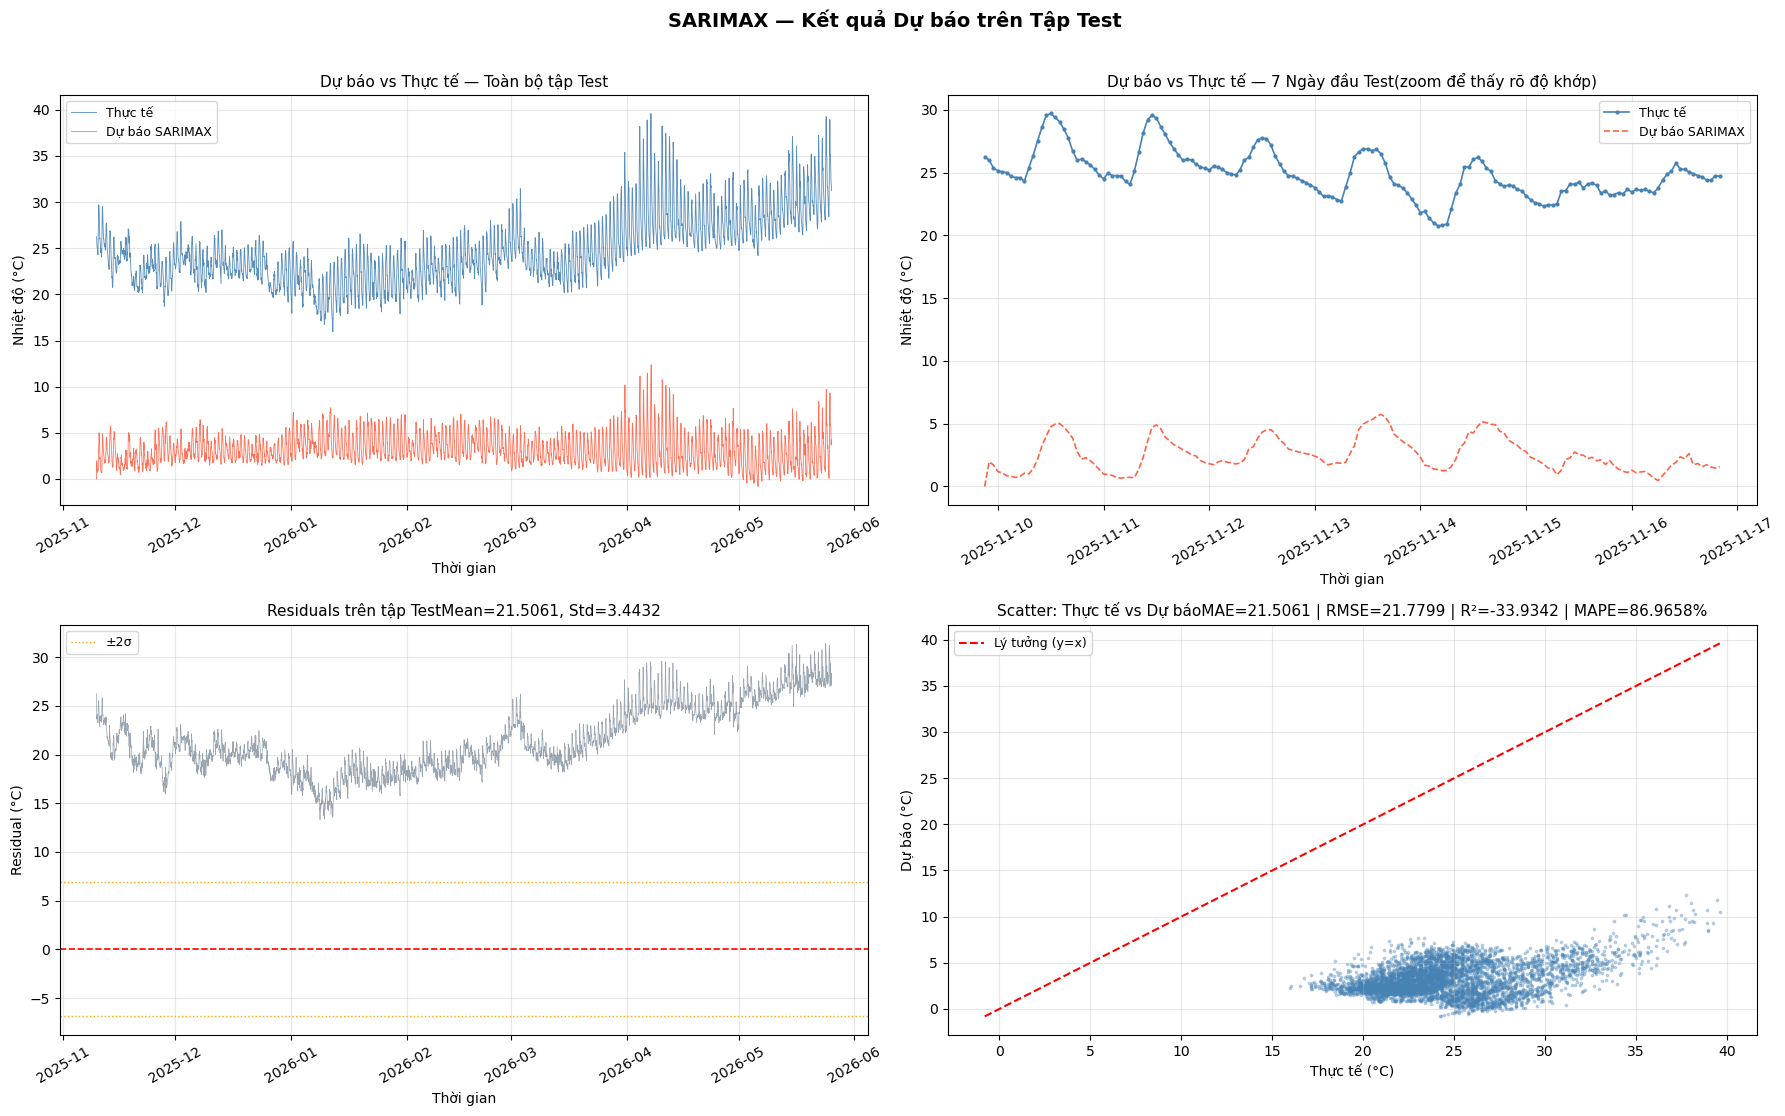

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

time_index = test_pca_df['time'].values

# ── 1. Dự báo vs Thực tế — toàn bộ test ─────────────────────────────────────
axes[0, 0].plot(time_index, y_true, color='steelblue', linewidth=0.6,
                alpha=0.9, label='Thực tế')
axes[0, 0].plot(time_index, y_pred, color='tomato', linewidth=0.6,
                alpha=0.9, label='Dự báo SARIMAX')
axes[0, 0].set_title('Dự báo vs Thực tế — Toàn bộ tập Test', fontsize=11)
axes[0, 0].set_xlabel('Thời gian')
axes[0, 0].set_ylabel('Nhiệt độ (°C)')
axes[0, 0].legend(fontsize=9)
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].grid(True, alpha=0.3)

# ── 2. Dự báo vs Thực tế — zoom 7 ngày ──────────────────────────────────────
zoom_n = 7 * 24
axes[0, 1].plot(time_index[:zoom_n], y_true[:zoom_n],
                color='steelblue', linewidth=1.2,
                marker='o', markersize=2, label='Thực tế')
axes[0, 1].plot(time_index[:zoom_n], y_pred[:zoom_n],
                color='tomato', linewidth=1.2,
                linestyle='--', label='Dự báo SARIMAX')
axes[0, 1].set_title('Dự báo vs Thực tế — 7 Ngày đầu Test(zoom để thấy rõ độ khớp)', fontsize=11)
axes[0, 1].set_xlabel('Thời gian')
axes[0, 1].set_ylabel('Nhiệt độ (°C)')
axes[0, 1].legend(fontsize=9)
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].grid(True, alpha=0.3)

# ── 3. Residuals theo thời gian ──────────────────────────────────────────────
axes[1, 0].plot(time_index, residuals_test,
                color='slategray', linewidth=0.5, alpha=0.7)
axes[1, 0].axhline(0,  color='red',    linestyle='--', linewidth=1.2)
axes[1, 0].axhline( residuals_test.std()*2, color='orange',
                    linestyle=':', linewidth=1, label='±2σ')
axes[1, 0].axhline(-residuals_test.std()*2, color='orange',
                    linestyle=':', linewidth=1)
axes[1, 0].set_title(
    f'Residuals trên tập Test'
    f'Mean={residuals_test.mean():.4f}, Std={residuals_test.std():.4f}',
    fontsize=11)
axes[1, 0].set_xlabel('Thời gian')
axes[1, 0].set_ylabel('Residual (°C)')
axes[1, 0].legend(fontsize=9)
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].grid(True, alpha=0.3)

# ── 4. Scatter: Thực tế vs Dự báo ───────────────────────────────────────────
axes[1, 1].scatter(y_true, y_pred, s=3, alpha=0.3, color='steelblue')
# Đường lý tưởng y=x
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val],
                color='red', linestyle='--', linewidth=1.5, label='Lý tưởng (y=x)')
axes[1, 1].set_title(
    f'Scatter: Thực tế vs Dự báo'
    f'MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f} | MAPE={mape:.4f}%',
    fontsize=11)
axes[1, 1].set_xlabel('Thực tế (°C)')
axes[1, 1].set_ylabel('Dự báo (°C)')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('SARIMAX — Kết quả Dự báo trên Tập Test', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [15]:
print("=" * 60)
print("TÓM TẮT KẾT QUẢ — SARIMAX TESTING")
print("=" * 60)
print(f"  Mô hình     : SARIMAX{res_sarimax.model.order} — phiên bản FE_PCA")
print(f"  Tập test    : {len(y_test):,} mẫu")
print(f"  Thời gian   : {test_pca_df['time'].min()} → {test_pca_df['time'].max()}")
print(f"  Exog        : {pca_exog_cols}")
print()
print(f"  MAE         : {mae:.4f} °C")
print(f"  RMSE        : {rmse:.4f} °C")
print(f"  R²          : {r2:.4f}")
print(f"  MAPE        : {mape:.4f} %")
print(f"  Ljung-Box   : p={lb_pval:.4f} → {lb_pass}")
print("=" * 60)

TÓM TẮT KẾT QUẢ — SARIMAX TESTING
  Mô hình     : SARIMAX(1, 0, 0) — phiên bản FE_PCA
  Tập test    : 4,731 mẫu
  Thời gian   : 2025-11-09 21:00:00 → 2026-05-25 23:00:00
  Exog        : ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month']

  MAE         : 21.5061 °C
  RMSE        : 21.7799 °C
  R²          : -33.9342
  MAPE        : 86.9658 %
  Ljung-Box   : p=0.0000 → FAIL (còn tự tương quan)
